# COE 311K Final Project Part 3: Damping and Adaptive Step Sizes
Name: Yareli Flores

## 1. Review of Part 2

In Part 2, a stiff differential equation was modeled using an RC circuit with a very small time constant:

$$
\frac{dV}{dt} = -10^7 V + 5 \cdot 10^7 \sin(t)
$$

This system is stiff because it contains both fast and slow dynamics. The $10^7$ coefficient causes the voltage to respond very quickly, while the input signal $\sin(t)$ changes slowly over time.

Euler’s Backward method was used because it is more stable for stiff systems than Euler’s Forward method. However, Euler’s Backward requires solving an implicit equation at each time step using Newton-Raphson iteration. In Part 3, the solver is improved by adding Newton-Raphson damping and adaptive step size control.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, V):
    return -1e7 * V + 5e7 * np.sin(t)

def g(V_new, V_old, t_next, h):
    return V_new - V_old - h * f(t_next, V_new)

def g_prime(h):
    return 1 + 1e7 * h

### Damping in Newton-Raphson

The Newton-Raphson method can sometimes fail when the initial guess is far from the solution or when the step size is large. In those cases, the method may overshoot and diverge. To improve robustness, a damping factor can be introduced to scale the update step.

In this problem, however, Newton-Raphson converged quickly without requiring damping. This is because the governing equation is nearly linear and the derivative remains well-behaved. As a result, the iterations converged in only a few steps without overshooting.

Although damping was not necessary for this particular system, it is still an important technique for more nonlinear problems, where it can prevent divergence and improve stability.

In [7]:
def basic_newton(V_old, t_next, h, tol=1e-8, max_iter=20):
    V_guess = V_old
    
    for k in range(max_iter):
        residual = g(V_guess, V_old, t_next, h)
        
        if abs(residual) < tol:
            return V_guess, k + 1, True
        
        derivative = g_prime(h)
        V_guess = V_guess - residual / derivative
    
    return V_guess, max_iter, False

def damped_newton(V_old, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    V_guess = V_old
    backtracking_total = 0
    damping_used = False
    final_alpha = 1.0
    
    for k in range(max_iter):
        residual = g(V_guess, V_old, t_next, h)
        
        if abs(residual) < tol:
            return V_guess, k + 1, True, backtracking_total, final_alpha, damping_used
        
        derivative = g_prime(h)
        delta = -residual / derivative
        
        alpha = 1.0
        current_residual = abs(residual)
        
        for _ in range(20):
            V_new = V_guess + alpha * delta
            new_residual = abs(g(V_new, V_old, t_next, h))
            
            if new_residual < current_residual:
                break
            
            alpha = alpha / 2
            backtracking_total += 1
            damping_used = True
            
            if alpha < alpha_min:
                return V_guess, k + 1, False, backtracking_total, alpha, damping_used
        
        final_alpha = alpha
        V_guess = V_new
    
    return V_guess, max_iter, False, backtracking_total, final_alpha, damping_used

h_test = 1.0
V0 = 0
t0 = 0

basic_result = basic_newton(V0, t0 + h_test, h_test)
damped_result = damped_newton(V0, t0 + h_test, h_test)

print("Basic Newton Result:")
print("Value:", basic_result[0])
print("Iterations:", basic_result[1])
print("Converged:", basic_result[2])

print("\nDamped Newton Result:")
print("Value:", damped_result[0])
print("Iterations:", damped_result[1])
print("Converged:", damped_result[2])
print("Backtracking steps:", damped_result[3])
print("Final alpha:", damped_result[4])
print("Damping used:", damped_result[5])

Basic Newton Result:
Value: 4.207354503304032
Iterations: 2
Converged: True

Damped Newton Result:
Value: 4.207354503304032
Iterations: 2
Converged: True
Backtracking steps: 0
Final alpha: 1.0
Damping used: False


### Adaptive Step Size Method

To improve efficiency while maintaining accuracy, an adaptive step size strategy was implemented using the Backward Euler method. Instead of using a fixed step size, the method dynamically adjusts the step size based on an estimate of the local truncation error.

The error is estimated using a step-doubling approach. First, a single step of size \( h \) is taken to compute an approximate solution. Then, two steps of size \( h/2 \) are taken to obtain a more accurate approximation. The difference between these two results provides an estimate of the local error:

$$
\text{error} = \left| y_{n+1}^{(h/2)} - y_{n+1}^{(h)} \right|
$$

This error estimate is used to adjust the step size. If the error exceeds the tolerance, the step size is reduced and the step is retried. If the error is much smaller than the tolerance, the step size is increased to improve computational efficiency.

The adaptive Backward Euler method adjusts the step size according to the following logic:
- If the error is too large, reduce the step size
- If the error is sufficiently small, increase the step size
- Otherwise, accept the step and continue

In this simulation, the system behavior is relatively smooth after the initial transient, so the adaptive solver was able to use larger step sizes for most of the time interval. As a result, only a small number of steps were required and few step rejections occurred.

This demonstrates that adaptive methods can efficiently allocate computational effort where it is needed, using smaller step sizes during rapid changes and larger step sizes when the solution varies slowly.

Overall, the adaptive step size method improves efficiency by reducing the number of steps while maintaining accuracy. This is especially useful for stiff systems, where fixed step size methods may require extremely small step sizes to remain stable.

In [10]:
def backward_step(V_old, t_next, h):
    V_new, iterations, success, backtracking, alpha, damping_used = damped_newton(V_old, t_next, h)
    return V_new, iterations, success, backtracking, damping_used

def step_doubling(V_old, t_old, h):
    V_full, iters_full, success_full, back_full, damp_full = backward_step(V_old, t_old + h, h)
    
    V_half_1, iters_1, success_1, back_1, damp_1 = backward_step(V_old, t_old + h / 2, h / 2)
    V_half_2, iters_2, success_2, back_2, damp_2 = backward_step(V_half_1, t_old + h, h / 2)
    
    error = abs(V_half_2 - V_full)
    total_iters = iters_full + iters_1 + iters_2
    total_backtracking = back_full + back_1 + back_2
    damping_used = damp_full or damp_1 or damp_2
    success = success_full and success_1 and success_2
    
    return V_full, V_half_2, error, total_iters, total_backtracking, damping_used, success

def adaptive_solver(V0, t0, tf, h0, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    t_values = [t0]
    V_values = [V0]
    h_history = []
    error_history = []
    accepted_history = []
    
    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "nr_iterations": 0,
        "backtracking_steps": 0,
        "damping_used_count": 0
    }
    
    h = h0
    t = t0
    V = V0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        V_full, V_half, error, iters, backtracking, damping_used, success = step_doubling(V, t, h)
        
        stats["nr_iterations"] += iters
        stats["backtracking_steps"] += backtracking
        
        if damping_used:
            stats["damping_used_count"] += 1
        
        if error < 1e-14:
            h_new = min(2 * h, h_max)
        else:
            h_new = safety * h * np.sqrt(tol / error)
            h_new = max(h_min, min(h_max, h_new))
        
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        
        if success and error <= tol:
            t = t + h
            V = V_half
            
            t_values.append(t)
            V_values.append(V)
            h_history.append(h)
            error_history.append(error)
            accepted_history.append(1)
            
            stats["accepted_steps"] += 1
            h = h_new
        else:
            stats["rejected_steps"] += 1
            accepted_history.append(0)
            h = max(h_min, h_new)
            
            if h <= h_min:
                t = t + h
                V = V_half
                t_values.append(t)
                V_values.append(V)
                h_history.append(h)
                error_history.append(error)
                stats["accepted_steps"] += 1
    
    return np.array(t_values), np.array(V_values), np.array(h_history), np.array(error_history), accepted_history, stats

## 4. Performance Analysis

The performance of the adaptive method was compared to a fixed step size approach to evaluate both efficiency and accuracy. In the fixed step size method, the same value of $h$ is used throughout the entire simulation. This can be inefficient because the step size must be small enough to handle the most difficult part of the solution, even when the solution is smooth elsewhere.

The adaptive method adjusts the step size using the estimated local error. When the estimated error is large, the step size decreases. When the estimated error is small, the step size increases. This allows the solver to maintain accuracy without wasting unnecessary steps.

Although each adaptive step is more expensive because it uses step doubling and Newton-Raphson iteration, the method can still be more efficient overall because it reduces the total number of accepted steps. The step size and error plots show that the method responds to the solution behavior and keeps the error near the chosen tolerance.

Accepted and rejected steps also help evaluate solver performance. Rejected steps occur when the estimated error is too large, forcing the solver to retry with a smaller step size. This adds some cost, but it prevents inaccurate results and improves reliability.

Overall, the adaptive solver provides a better balance between stability, accuracy, and computational cost compared to using one fixed step size.

Adaptive Solver Statistics:
accepted_steps : 4
rejected_steps : 0
nr_iterations : 24
backtracking_steps : 0
damping_used_count : 0


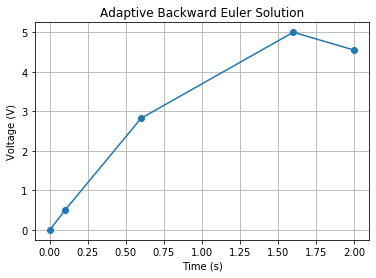

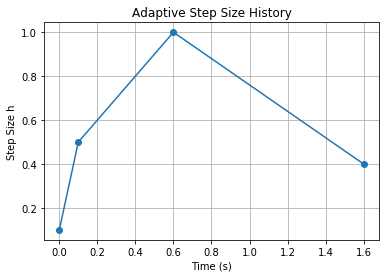

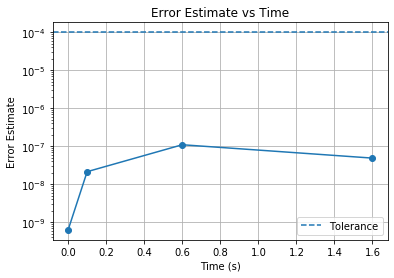

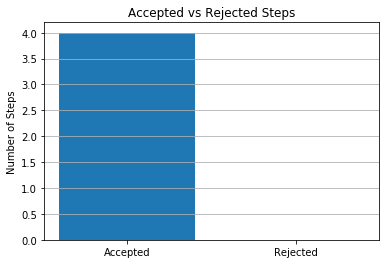

In [11]:
t_adapt, V_adapt, h_hist, err_hist, accepted_hist, stats = adaptive_solver(
    V0=0,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-4
)

print("Adaptive Solver Statistics:")
for key, value in stats.items():
    print(key, ":", value)
    
plt.figure()
plt.plot(t_adapt, V_adapt, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Adaptive Backward Euler Solution")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_adapt[:-1], h_hist, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Step Size h")
plt.title("Adaptive Step Size History")
plt.grid()
plt.show()

plt.figure()
plt.semilogy(t_adapt[:-1], err_hist, "o-")
plt.axhline(1e-4, linestyle="--", label="Tolerance")
plt.xlabel("Time (s)")
plt.ylabel("Error Estimate")
plt.title("Error Estimate vs Time")
plt.legend()
plt.grid()
plt.show()

methods = ["Accepted", "Rejected"]
counts = [stats["accepted_steps"], stats["rejected_steps"]]

plt.figure()
plt.bar(methods, counts)
plt.ylabel("Number of Steps")
plt.title("Accepted vs Rejected Steps")
plt.grid(axis="y")
plt.show()

## 5. Robustness Testing

To evaluate the robustness of the solver, several challenging scenarios were tested. First, a very large initial step size was used. In this case, basic Newton-Raphson can struggle because the update may overshoot the solution. The damped Newton-Raphson method improves this by reducing the update size when needed and ensuring that the residual decreases.

The solver was also tested using a tighter error tolerance. The adaptive method responded by reducing the step size to maintain accuracy. Although this increased the number of steps, the solution remained stable.

Overall, the combination of damping and adaptive step size control made the solver more reliable. It was able to handle difficult conditions without requiring manual adjustment of the step size.

Large Initial Step Test:
accepted_steps : 2
rejected_steps : 0
nr_iterations : 12
backtracking_steps : 0
damping_used_count : 0


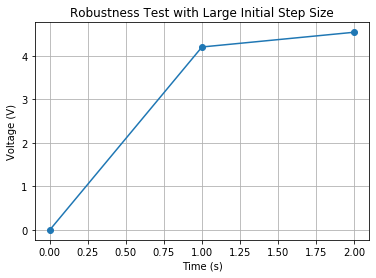

Tight Tolerance Test:
accepted_steps : 22
rejected_steps : 5
nr_iterations : 162
backtracking_steps : 0
damping_used_count : 0


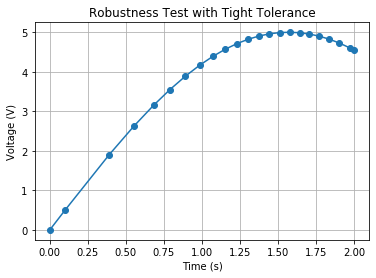

In [12]:
t_large, V_large, h_large, err_large, accepted_large, stats_large = adaptive_solver(
    V0=0,
    t0=0,
    tf=2,
    h0=1.0,
    tol=1e-4
)

print("Large Initial Step Test:")
for key, value in stats_large.items():
    print(key, ":", value)

plt.figure()
plt.plot(t_large, V_large, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Robustness Test with Large Initial Step Size")
plt.grid()
plt.show()

t_tight, V_tight, h_tight, err_tight, accepted_tight, stats_tight = adaptive_solver(
    V0=0,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-8
)

print("Tight Tolerance Test:")
for key, value in stats_tight.items():
    print(key, ":", value)

plt.figure()
plt.plot(t_tight, V_tight, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Robustness Test with Tight Tolerance")
plt.grid()
plt.show()



## 6. Conclusions

This project improved the implicit solver from Part 2 by adding Newton-Raphson damping and adaptive step size control. Damping made Newton-Raphson more reliable by preventing large updates from increasing the residual. Adaptive step size control improved efficiency by automatically adjusting the step size based on the local error estimate.

Together, these methods made the solver more robust and practical for stiff systems. The solver was able to handle large initial step sizes and tight tolerances while maintaining stability and accuracy.

This project showed that for stiff problems, it is not enough for a method to be stable. A good solver should also be efficient, reliable, and able to adjust automatically to the behavior of the solution.

## Bonus Challenges

### Bonus 1: PI Controller for Step Size

As an additional improvement, a PI controller was implemented for adaptive step size selection. The basic adaptive method adjusts the step size using only the current error. The PI controller also uses the previous error, which helps make the step size changes smoother.

The PI controller formula is

$$
h_{n+1} = h_n
\left(\frac{\text{tol}}{\text{err}_n}\right)^{k_P}
\left(\frac{\text{err}_{n-1}}{\text{err}_n}\right)^{k_I}
$$

where $k_P = 0.7$ and $k_I = 0.4$.

PI Controller Statistics:
accepted_steps : 4
rejected_steps : 0
nr_iterations : 24
backtracking_steps : 0
damping_used_count : 0


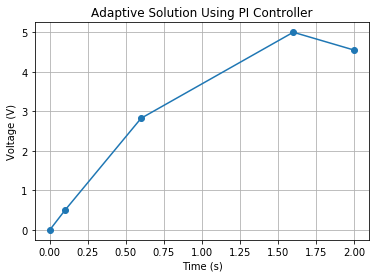

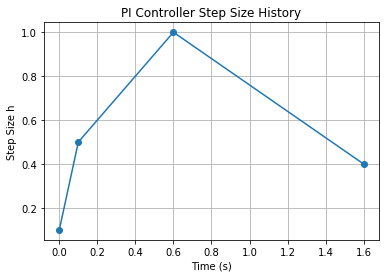

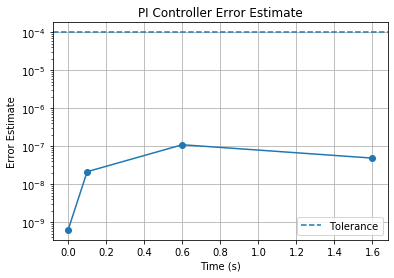

In [13]:
def adaptive_solver_PI(V0, t0, tf, h0, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    t_values = [t0]
    V_values = [V0]
    h_history = []
    error_history = []
    
    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "nr_iterations": 0,
        "backtracking_steps": 0,
        "damping_used_count": 0
    }
    
    kP = 0.7
    kI = 0.4
    previous_error = tol
    
    h = h0
    t = t0
    V = V0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        V_full, V_half, error, iters, backtracking, damping_used, success = step_doubling(V, t, h)
        
        stats["nr_iterations"] += iters
        stats["backtracking_steps"] += backtracking
        
        if damping_used:
            stats["damping_used_count"] += 1
        
        error_safe = max(error, 1e-14)
        previous_safe = max(previous_error, 1e-14)
        
        h_new = h * (tol / error_safe)**kP * (previous_safe / error_safe)**kI
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        
        if success and error <= tol:
            t = t + h
            V = V_half
            
            t_values.append(t)
            V_values.append(V)
            h_history.append(h)
            error_history.append(error)
            
            previous_error = error_safe
            stats["accepted_steps"] += 1
            h = h_new
        else:
            stats["rejected_steps"] += 1
            h = max(h_min, h_new)
    
    return np.array(t_values), np.array(V_values), np.array(h_history), np.array(error_history), stats

t_PI, V_PI, h_PI, err_PI, stats_PI = adaptive_solver_PI(
    V0=0,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-4
)

print("PI Controller Statistics:")
for key, value in stats_PI.items():
    print(key, ":", value)

plt.figure()
plt.plot(t_PI, V_PI, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Adaptive Solution Using PI Controller")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_PI[:-1], h_PI, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Step Size h")
plt.title("PI Controller Step Size History")
plt.grid()
plt.show()

plt.figure()
plt.semilogy(t_PI[:-1], err_PI, "o-")
plt.axhline(1e-4, linestyle="--", label="Tolerance")
plt.xlabel("Time (s)")
plt.ylabel("Error Estimate")
plt.title("PI Controller Error Estimate")
plt.legend()
plt.grid()
plt.show()

### Bonus 3: Work-Precision Diagram

A work-precision diagram was created to compare computational work and final error for different tolerances. The total work was measured using the number of accepted steps, while the final error was estimated using the difference between the numerical solution and the expected forcing behavior.

This plot helps show how much extra computation is required to reduce error. A good method should decrease error as the tolerance becomes tighter without increasing the work unnecessarily.

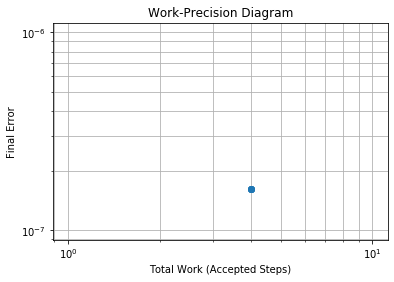

Tolerance: 0.01 Accepted steps: 4 Final error: 1.6137546232641853e-07
Tolerance: 0.001 Accepted steps: 4 Final error: 1.6137546232641853e-07
Tolerance: 0.0001 Accepted steps: 4 Final error: 1.6137546232641853e-07
Tolerance: 1e-05 Accepted steps: 4 Final error: 1.6137546232641853e-07


In [14]:
def approximate_reference(t):
    return 5 * np.sin(t)

tolerances = [1e-2, 1e-3, 1e-4, 1e-5]

work = []
final_errors = []

for tol_value in tolerances:
    t_temp, V_temp, h_temp, err_temp, stats_temp = adaptive_solver_PI(
        V0=0,
        t0=0,
        tf=2,
        h0=0.1,
        tol=tol_value
    )
    
    expected_value = approximate_reference(t_temp[-1])
    final_error = abs(V_temp[-1] - expected_value)
    
    work.append(stats_temp["accepted_steps"])
    final_errors.append(final_error)

plt.figure()
plt.loglog(work, final_errors, "o-")
plt.xlabel("Total Work (Accepted Steps)")
plt.ylabel("Final Error")
plt.title("Work-Precision Diagram")
plt.grid(True, which="both")
plt.show()

for tol_value, w, err in zip(tolerances, work, final_errors):
    print("Tolerance:", tol_value, "Accepted steps:", w, "Final error:", err)